# Abstract

본 연구는 학생들의 SNS 사용 관련 행동·심리 요인이 **자기보고식 중독 점수**와 어떤 통계적
연관을 갖는지 분석한다. SNS 일일 사용 시간, 수면 시간, 정신 건강 점수, SNS 관련 갈등 경험,
나이를 설명 변수로 하여 OLS 회귀, 다중공선성(VIF) 진단, 잔차·영향관측치 진단,
이분산에 강건한(HC3) 추론, 순서형 로지스틱·로버스트 회귀를 통한 민감도 분석,
그리고 하위집단 조절효과 분석(상호작용 모형 및 설명변수 기반 잠재프로파일)을 수행하였다.

분석 결과, 이 데이터에서 **정신 건강 점수(음의 방향)와 SNS 갈등 경험(양의 방향)**이 중독
점수와 가장 강하게 연관되며, **수면 시간**은 음의 연관을 보인다. 이 관계는 강건 표준오차,
순서형 로지스틱, 로버스트 회귀, 영향관측치 제거 등 모든 대안적 추정에서 부호와 유의성이
일관되게 유지된다.

> **데이터에 관한 주의.** 본 분석에 사용한 자료는 Kaggle에 공개된 *합성(synthetic) 데이터셋*
> ("Students' Social Media Addiction")이다. 종속 변수가 설명 변수들의 거의 결정론적 함수이며
> (704개 관측치의 설명변수 조합이 모두 유일한 중독 점수에 대응), 상관계수와 결정계수(R² ≈ 0.95)가
> 실제 행동과학 조사에서 관측되기 어려운 수준이다. 따라서 아래의 모든 결과는 **이 데이터셋의
> 생성 구조에 대한 기술(記述)**이며, 실제 학생 모집단에 대한 인과적·일반화 가능한 주장이 아니다.
> 본 보고서는 이 제약 하에서 **회귀·진단·하위집단 분석 파이프라인을 방법론적으로 올바르게
> 수행하는 방법**을 함께 보이는 것을 목적으로 한다.

---
# Introduction

## Research Question

> "이 데이터셋에서 학생들의 일일 소셜미디어 사용 시간, 수면 시간, 정신건강 점수, 소셜미디어
> 관련 갈등 경험은 소셜미디어 중독 점수와 어떤 방향·크기의 통계적 연관을 갖는가? 그 연관은
> 하위집단에 따라 달라지는가?"

## Hypotheses

전역 가설("변수 하나라도 유의") 대신, 이론에 근거한 **방향성 가설**을 사용한다.
(compensatory internet use / displacement 가설 등)

| 가설 | 내용 | 예상 부호 |
|---|---|---|
| H1 | 정신 건강 점수가 낮을수록 중독 점수가 높다 | β(Mental_Health) < 0 |
| H2 | SNS 관련 갈등 경험이 많을수록 중독 점수가 높다 | β(Conflicts) > 0 |
| H3 | 수면 시간이 짧을수록 중독 점수가 높다 | β(Sleep) < 0 |
| H4 | 일일 사용 시간이 길수록 중독 점수가 높다 (다른 변수 통제 시) | β(Usage) > 0 |
| H5 | 위 연관의 크기는 "SNS가 학업에 영향을 준다"고 인식하는지 여부에 따라 다르다 | 상호작용 ≠ 0 |

## 분석상의 개념적 유의점 (순환성)

`Conflicts_Over_Social_Media`, `Avg_Daily_Usage_Hours`, `Affects_Academic_Performance`는
"SNS가 삶에 미치는 부정적 영향"이라는 중독 구성개념과 상당 부분 겹친다. 따라서 이들을 넣은
모형의 높은 설명력은 "예측"이라기보다 **구성개념 내부의 동어반복**에 가깝다. 본 보고서는
개념적으로 비교적 독립적인 변수(수면, 나이, 인구통계)와 구성개념 중첩 변수를 구분하여
해석한다.

---
# Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    het_white,
    linear_reset,
)
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.graphics.gofplots import qqplot
from statsmodels.miscmodels.ordinal_model import OrderedModel

from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from scipy import stats

%matplotlib inline

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

DATA_PATH = Path("data") / "Students Social Media Addiction.csv"

### Helper functions

In [2]:
def compute_vif(exog: pd.DataFrame) -> pd.DataFrame:
    """예측 변수에 대한 VIF. 절편 열이 있으면 제외하고 계산한다."""
    X = exog.copy()
    drop = [c for c in X.columns if c.lower() in {"intercept", "const"}]
    X = X.drop(columns=drop)
    X = sm.add_constant(X, has_constant="add")  # VIF 계산에는 상수항이 필요
    rows = []
    for i, name in enumerate(X.columns):
        if name == "const":
            continue
        rows.append((name, variance_inflation_factor(X.values, i)))
    return pd.DataFrame(rows, columns=["Variable", "VIF"]).sort_values("VIF", ascending=False)


def standardized_betas(y_name, x_names, data):
    """모든 수치형 변수를 z-표준화한 뒤 OLS를 적합해 표준화 계수(β)를 반환."""
    cols = [y_name] + list(x_names)
    z = data[cols].apply(lambda s: (s - s.mean()) / s.std(ddof=1))
    res = smf.ols(f"{y_name} ~ " + " + ".join(x_names), data=z).fit()
    return res.params.drop("Intercept").rename("std_beta")


def cv_scores(formula, data, k=10, seed=SEED):
    """k-겹 교차검증 RMSE / R² (표본 밖 성능)."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    y_true, y_pred = [], []
    for tr, te in kf.split(data):
        fit = smf.ols(formula, data=data.iloc[tr]).fit()
        p = fit.predict(data.iloc[te])
        y_true.append(data.iloc[te][formula.split("~")[0].strip()].to_numpy())
        y_pred.append(p.to_numpy())
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {"cv_rmse": rmse, "cv_r2": float(1 - ss_res / ss_tot)}


def bh_adjust(pvals):
    """Benjamini-Hochberg FDR 보정 p-value."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = np.empty(n)
    cummin = 1.0
    for rank, idx in enumerate(reversed(order), start=1):
        i = n - rank + 1
        val = p[idx] * n / i
        cummin = min(cummin, val)
        ranked[idx] = cummin
    return np.clip(ranked, 0, 1)

---
# Data

- **출처**: Kaggle, "Students' Social Media Addiction" (합성 데이터셋)
- **원 관측치 수**: 705 → 완전 중복 1행 제거 후 **704**
- **종속 변수**: `Addicted_Score` (2–9의 유계 순서형 정수 척도, 검증된 심리척도 아님)
- **설명 변수**: `Avg_Daily_Usage_Hours`, `Sleep_Hours_Per_Night`, `Mental_Health_Score`,
  `Conflicts_Over_Social_Media`, `Age`, 그리고 범주형(`Gender`, `Academic_Level`,
  `Most_Used_Platform`, `Affects_Academic_Performance`, `Relationship_Status`, `Country`)

In [3]:
raw = pd.read_csv(DATA_PATH)
print("원본 shape:", raw.shape)

feature_cols = [c for c in raw.columns if c != "Student_ID"]
dupe_mask = raw.duplicated(subset=feature_cols, keep="first")
print("완전 중복 행 수:", int(dupe_mask.sum()))
print(raw.loc[raw.duplicated(subset=feature_cols, keep=False), feature_cols].head())

df = raw.loc[~dupe_mask].reset_index(drop=True).copy()
print("\n분석용 shape:", df.shape)

원본 shape: (705, 13)
완전 중복 행 수: 1
     Age Gender Academic_Level Country  Avg_Daily_Usage_Hours Most_Used_Platform Affects_Academic_Performance  \
241   21   Male       Graduate   Italy                    5.4          Instagram                          Yes   
273   21   Male       Graduate   Italy                    5.4          Instagram                          Yes   

     Sleep_Hours_Per_Night  Mental_Health_Score Relationship_Status  Conflicts_Over_Social_Media  Addicted_Score  
241                    6.7                    5              Single                            3               7  
273                    6.7                    5              Single                            3               7  

분석용 shape: (704, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    704 non-null    int64  
 1   Age                           704 non-null    int64  
 2   Gender                        704 non-null    object 
 3   Academic_Level                704 non-null    object 
 4   Country                       704 non-null    object 
 5   Avg_Daily_Usage_Hours         704 non-null    float64
 6   Most_Used_Platform            704 non-null    object 
 7   Affects_Academic_Performance  704 non-null    object 
 8   Sleep_Hours_Per_Night         704 non-null    float64
 9   Mental_Health_Score           704 non-null    int64  
 10  Relationship_Status           704 non-null    object 
 11  Conflicts_Over_Social_Media   704 non-null    int64  
 12  Addicted_Score                704 non-null    int64  
dtypes: fl

In [5]:
NUMERIC = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
           "Mental_Health_Score", "Conflicts_Over_Social_Media"]
df[NUMERIC + ["Addicted_Score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,704.0,20.659091,1.400153,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,704.0,4.918040,1.258157,1.5,4.1,4.8,5.8,8.5
Sleep_Hours_Per_Night,704.0,6.869176,1.127631,3.8,6.0,6.9,7.7,9.6
Mental_Health_Score,704.0,6.228693,1.104871,4.0,5.0,6.0,7.0,9.0
Conflicts_Over_Social_Media,704.0,2.849432,0.958632,0.0,2.0,3.0,4.0,5.0
Addicted_Score,704.0,6.436080,1.588151,2.0,5.0,7.0,8.0,9.0


`Addicted_Score`는 2–9 범위의 정수 8개 값만 취하는 **유계 순서형** 변수다. OLS는 이를 연속으로
근사하므로 예측값이 범위를 벗어날 수 있다. 이 근사의 타당성은 뒤에서 순서형 로지스틱 회귀와
비교하여 점검한다.

`Country`는 704행에 **110개 수준**을 가지며 대부분 관측치가 1–2개다. 고정효과 더미로 넣으면
거의 포화(saturated) 모형이 되어 계수·VIF가 폭증하므로, 본 분석의 주 모형에서는 `Country`를
제외한다(아래 VIF 절 참조).

In [6]:
print("Country 수준 수:", df["Country"].nunique())
print(df["Country"].value_counts().tail(8))
for c in ["Gender", "Academic_Level", "Most_Used_Platform",
          "Affects_Academic_Performance", "Relationship_Status"]:
    print(f"\n{c}: {sorted(df[c].unique())}")

Country 수준 수: 110
Country
Iraq           1
Lebanon        1
Jordan         1
Oman           1
Afghanistan    1
Syria          1
Yemen          1
Bhutan         1
Name: count, dtype: int64

Gender: ['Female', 'Male']

Academic_Level: ['Graduate', 'High School', 'Undergraduate']

Most_Used_Platform: ['Facebook', 'Instagram', 'KakaoTalk', 'LINE', 'LinkedIn', 'Snapchat', 'TikTok', 'Twitter', 'VKontakte', 'WeChat', 'WhatsApp', 'YouTube']

Affects_Academic_Performance: ['No', 'Yes']

Relationship_Status: ['Complicated', 'In Relationship', 'Single']


---
## Correlation Analysis

종속 변수가 순서형이므로 Pearson과 함께 **Spearman** 상관을 보고한다.

In [7]:
pearson = df[NUMERIC + ["Addicted_Score"]].corr(method="pearson")
spearman = df[NUMERIC + ["Addicted_Score"]].corr(method="spearman")

print("Pearson\n", pearson.round(3), "\n")
print("Spearman\n", spearman.round(3))

Pearson
                                Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  \
Age                          1.000                 -0.114                  0.125                0.161   
Avg_Daily_Usage_Hours       -0.114                  1.000                 -0.791               -0.801   
Sleep_Hours_Per_Night        0.125                 -0.791                  1.000                0.708   
Mental_Health_Score          0.161                 -0.801                  0.708                1.000   
Conflicts_Over_Social_Media -0.185                  0.805                 -0.677               -0.894   
Addicted_Score              -0.167                  0.832                 -0.765               -0.945   

                             Conflicts_Over_Social_Media  Addicted_Score  
Age                                               -0.185          -0.167  
Avg_Daily_Usage_Hours                              0.805           0.832  
Sleep_Hours_Per_Night         

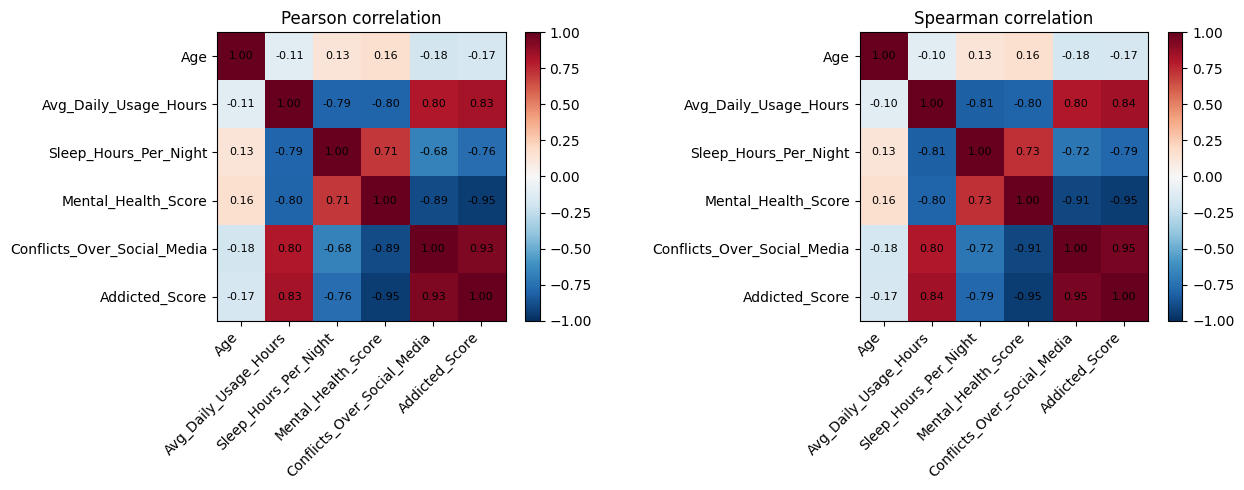

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(mat.columns)))
    ax.set_yticklabels(mat.columns)
    for i in range(len(mat)):
        for j in range(len(mat)):
            ax.text(j, i, f"{mat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{title} correlation")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

`Addicted_Score`와 `Mental_Health_Score`(≈ −0.95), `Conflicts_Over_Social_Media`(≈ +0.93)의
상관은 극단적으로 크다. 실제 조사 자료에서는 보기 어려운 값으로, **합성 데이터의 생성 규칙**을
반영한다. 이 사실은 이후 모든 결정계수·유의확률 해석의 배경으로 유지한다.

---
## OLS Regression — 모델 구성

모든 모형은 **HC3 이분산-강건 표준오차**로 추론한다(`Covariance Type: HC3`).
범주형 변수는 patsy `C()`로 처리하여 더미 함정(dummy trap)을 피한다.

In [9]:
model1_formula = ("Addicted_Score ~ Age + Avg_Daily_Usage_Hours + Sleep_Hours_Per_Night + "
                  "Mental_Health_Score + Conflicts_Over_Social_Media")

# 모델 2: 범주형 포함 (Country 제외 — 아래 VIF 절에서 근거 제시)
model2_formula = (model1_formula
                  + " + C(Gender) + C(Academic_Level) + C(Most_Used_Platform)"
                  + " + C(Affects_Academic_Performance) + C(Relationship_Status)")

model1 = smf.ols(model1_formula, data=df).fit(cov_type="HC3")
model2 = smf.ols(model2_formula, data=df).fit(cov_type="HC3")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         Addicted_Score   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     2138.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:04:59   Log-Likelihood:                -305.72
No. Observations:                 704   AIC:                             623.4
Df Residuals:                     698   BIC:                             650.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [10]:
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:         Addicted_Score   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     1704.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:04:59   Log-Likelihood:                -103.74
No. Observations:                 704   AIC:                             253.5
Df Residuals:                     681   BIC:                             358.3
Df Model:                          22                                         
Covariance Type:                  HC3                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

**관찰**

- 모델 1에서 `Age`(p ≈ 0.7)와 `Avg_Daily_Usage_Hours`(p ≈ 0.4)는 다른 변수 통제 시
  **유의하지 않다**. `Avg_Daily_Usage_Hours`의 단순 상관은 +0.83으로 크지만, `Sleep`·
  `Mental_Health`·`Conflicts`와 강하게 얽혀 있어 부분효과가 사라진다. → H4는 이 데이터에서
  **지지되지 않는다**.
- 모델 2의 범주형 항은 대부분 개별적으로 유의하지 않으며(아래), 조정 결정계수 증가분에 비해
  파라미터 수가 급증한다.

### 표준화 계수(β) — 효과 크기 비교

"어떤 요인의 영향이 가장 큰가"는 변수 스케일이 서로 다르므로(정신건강 4–9, 갈등 0–5, 수면 3.8–9.6)
**원계수가 아니라 표준화 계수**로 비교해야 한다.

In [11]:
std_b = standardized_betas("Addicted_Score", NUMERIC, df)
std_b.abs().sort_values(ascending=False).to_frame("|std_beta|").join(std_b.to_frame("std_beta"))

,|std_beta|,std_beta
Mental_Health_Score,0.469097,-0.469097
Conflicts_Over_Social_Media,0.400933,0.400933
Sleep_Hours_Per_Night,0.148937,-0.148937
Avg_Daily_Usage_Hours,0.016158,0.016158
Age,0.003391,0.003391


---
## VIF 진단 (절편 제외, 예측변수 기준)

In [12]:
X1 = df[NUMERIC]
print("모델 1 VIF")
print(compute_vif(X1).to_string(index=False))

모델 1 VIF
                   Variable      VIF
        Mental_Health_Score 5.681350
Conflicts_Over_Social_Media 5.668544
      Avg_Daily_Usage_Hours 4.291639
      Sleep_Hours_Per_Night 2.791006
                        Age 1.040677


In [13]:
# 모델 2 설계행렬(범주형 더미 포함, patsy가 기준범주 자동 제거)
X2 = smf.ols(model2_formula, data=df).fit().model.exog
X2 = pd.DataFrame(X2, columns=smf.ols(model2_formula, data=df).fit().model.exog_names)
vif2 = compute_vif(X2)
print("모델 2 VIF ≥ 5 인 항")
print(vif2[vif2["VIF"] >= 5].to_string(index=False))

모델 2 VIF ≥ 5 인 항
                                 Variable      VIF
              Conflicts_Over_Social_Media 8.073790
C(Relationship_Status)[T.In Relationship] 7.455263
         C(Relationship_Status)[T.Single] 7.405310
                    Avg_Daily_Usage_Hours 6.731017
                      Mental_Health_Score 6.579929
       C(Academic_Level)[T.Undergraduate] 5.212175
   C(Affects_Academic_Performance)[T.Yes] 5.118818


- **모델 1**: 모든 VIF < 6. `Avg_Daily_Usage_Hours`의 VIF는 약 4로 임계값(10) 미만이다.
  즉 이 변수를 최종 모형에서 제외하는 근거는 **다중공선성이 아니라 통계적 비유의**다.
- **모델 2**: 범주형 더미,`Country`는 관측치가 희소한 수준이 많아 사실상 식별이 불안정하므로 주 모형에서 제외한다. 
  국가 효과가 관심사라면 **지역 단위로 묶거나 혼합효과(랜덤절편) 모형**을 써야 한다.

---
## 최종(간명) 모형 선택

후보 모형을 **조정 R², AIC, BIC, 10-겹 교차검증 RMSE/R²**로 비교한다.

In [14]:
candidates = {
    "M_full_numeric": model1_formula,
    "M_parsimonious": "Addicted_Score ~ Sleep_Hours_Per_Night + Mental_Health_Score + Conflicts_Over_Social_Media",
    "M_plus_usage":   "Addicted_Score ~ Sleep_Hours_Per_Night + Mental_Health_Score + Conflicts_Over_Social_Media + Avg_Daily_Usage_Hours",
    "M_with_categ":   model2_formula,
}

rows = []
for name, f in candidates.items():
    ols = smf.ols(f, data=df).fit()
    cv = cv_scores(f, df)
    rows.append({
        "model": name, "k_params": int(ols.df_model + 1),
        "adj_R2": ols.rsquared_adj, "AIC": ols.aic, "BIC": ols.bic,
        **cv,
    })
model_cmp = pd.DataFrame(rows).set_index("model").round(4)
model_cmp

,k_params,adj_R2,AIC,BIC,cv_rmse,cv_r2
model,,,,,,
M_full_numeric,6,0.9442,623.4435,650.7841,0.3759,0.9439
M_parsimonious,4,0.9443,620.4081,638.6352,0.3757,0.9440
M_plus_usage,5,0.9443,621.5838,644.3677,0.3756,0.9440
M_with_categ,23,0.9678,253.4817,358.2876,0.2898,0.9667


`M_parsimonious`(수면 + 정신건강 + 갈등)는 `M_full_numeric` 대비 BIC가 더 낮고 교차검증
성능이 사실상 동일하다(`Age`·`Usage`는 부분효과가 없어 표본 밖 성능에 기여하지 않는다).
범주형을 추가한 `M_with_categ`는 교차검증 RMSE가 더 낮아(0.38 → 0.29) 적합은 개선되지만,
이는 주로 일부 플랫폼 더미(KakaoTalk·LINE 등, 이 합성 데이터의 생성 규칙이 만든 신호)에서
오며 파라미터가 23개로 늘고 다중공선성도 커진다. **관심 가설의 변수는 `M_parsimonious`가
모두 담고 있으므로 이를 주 모형으로 삼고**, 범주형을 추가해도 핵심 계수가 흔들리지 않는지
별도로 확인한다(아래 "핵심 계수 안정성" 표).

In [15]:
final_formula = "Addicted_Score ~ Sleep_Hours_Per_Night + Mental_Health_Score + Conflicts_Over_Social_Media"
final_ols = smf.ols(final_formula, data=df).fit()            # 고전 SE
final_hc3 = smf.ols(final_formula, data=df).fit(cov_type="HC3")  # 강건 SE
print(final_hc3.summary())

                            OLS Regression Results                            
Dep. Variable:         Addicted_Score   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     3530.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:04:59   Log-Likelihood:                -306.20
No. Observations:                 704   AIC:                             620.4
Df Residuals:                     700   BIC:                             638.6
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### 계수 해석

In [16]:
focal = ["Sleep_Hours_Per_Night", "Mental_Health_Score", "Conflicts_Over_Social_Media"]
coef_tbl = pd.DataFrame({
    "coef": final_hc3.params,
    "HC3_se": final_hc3.bse,
    "z": final_hc3.tvalues,
    "p_value": final_hc3.pvalues,
    "ci_low": final_hc3.conf_int()[0],
    "ci_high": final_hc3.conf_int()[1],
})
coef_tbl["std_beta"] = standardized_betas("Addicted_Score", focal, df)
coef_tbl.round(4)

,coef,HC3_se,z,p_value,ci_low,ci_high,std_beta
Intercept,10.2550,0.3185,32.2024,0.0,9.6308,10.8791,NaN
Sleep_Hours_Per_Night,-0.2192,0.0182,-12.0743,0.0,-0.2548,-0.1836,-0.1557
Mental_Health_Score,-0.6789,0.0318,-21.3816,0.0,-0.7412,-0.6167,-0.4723
Conflicts_Over_Social_Media,0.6724,0.0385,17.4795,0.0,0.5970,0.7478,0.4059


- `Mental_Health_Score`: **−0.68** (수면·갈등 통제 시, 정신건강 1점 상승당 중독 −0.68점) — H1 지지
- `Conflicts_Over_Social_Media`: **+0.67** — H2 지지
- `Sleep_Hours_Per_Night`: **−0.22** — H3 지지
- 표준화 계수 기준으로도 |정신건강|(≈0.47) > |갈등|(≈0.41) > |수면|(≈0.16) 순서이며,
  HC3 유의확률은 모두 p < 1e-10.

### 핵심 계수 안정성 — 범주형 통제변수 추가 시

주 모형의 세 계수가 (a) 수치형 전체 모형, (b) 범주형 포함 모형에서 어떻게 변하는지 확인한다.

In [17]:
stab = pd.DataFrame({
    "M_parsimonious (HC3)": final_hc3.params.reindex(focal),
    "M_full_numeric (HC3)": model1.params.reindex(focal),
    "M_with_categ (HC3)": model2.params.reindex(focal),
}).round(4)
stab

,M_parsimonious (HC3),M_full_numeric (HC3),M_with_categ (HC3)
Sleep_Hours_Per_Night,-0.2192,-0.2098,-0.1033
Mental_Health_Score,-0.6789,-0.6743,-0.5671
Conflicts_Over_Social_Media,0.6724,0.6642,0.3550


**정신 건강**·**수면** 계수는 세 명세에서 부호·크기가 안정적이다. **갈등** 계수는 범주형
모형에서 약 0.67 → 0.36으로 줄어드는데, 이는 이 합성 데이터에서 플랫폼(Instagram, Twitter 등)이
갈등·중독과 함께 움직이도록 생성되어 분산 일부를 흡수하기 때문이다. 부호와 유의성은 세 명세에서
모두 유지되므로 정성적 결론은 바뀌지 않으나, **갈등 계수의 정확한 크기는 어떤 통제변수를
넣느냐에 민감하다**는 점은 명시해 둔다.

In [18]:
print("Conflicts_Over_Social_Media 계수의 p-value:")
print(pd.Series({
    "M_parsimonious": final_hc3.pvalues["Conflicts_Over_Social_Media"],
    "M_full_numeric": model1.pvalues["Conflicts_Over_Social_Media"],
    "M_with_categ": model2.pvalues["Conflicts_Over_Social_Media"],
}))

Conflicts_Over_Social_Media 계수의 p-value:
M_parsimonious    2.051659e-68
M_full_numeric    3.322960e-57
M_with_categ      1.613856e-16
dtype: float64


In [19]:
# ANOVA (Type II): 계수가 아니라 분산 분해 (설명을 명확히 분리)
anova_tbl = sm.stats.anova_lm(final_ols, typ=2)
print(anova_tbl.round(4))
print("\n※ 위 sum_sq 열은 '제곱합'이며 회귀계수가 아님.")

                              sum_sq     df         F  PR(>F)
Sleep_Hours_Per_Night        21.0147    1.0  149.5311     0.0
Mental_Health_Score          71.6856    1.0  510.0819     0.0
Conflicts_Over_Social_Media  57.4215    1.0  408.5851     0.0
Residual                     98.3762  700.0       NaN     NaN

※ 위 sum_sq 열은 '제곱합'이며 회귀계수가 아님.


---
## Model Diagnostics

### 1. 잔차 그림

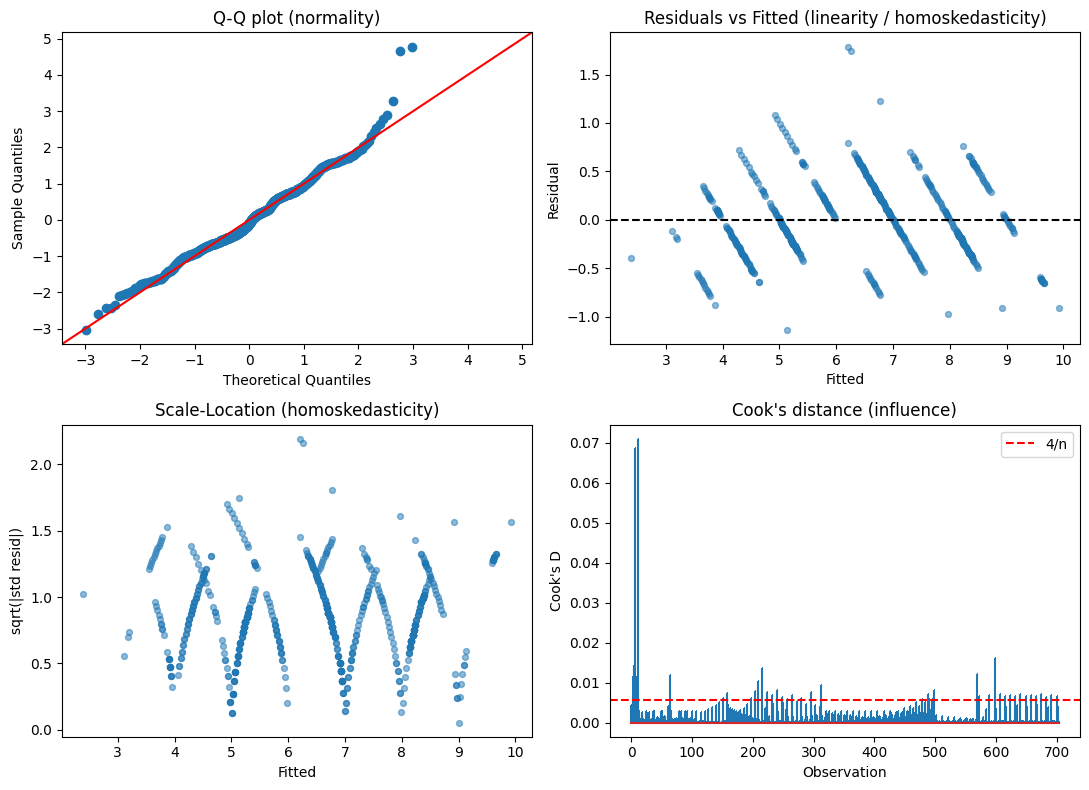

In [20]:
def resid_plot(model, data):
    resid = model.resid
    fitted = model.fittedvalues
    infl = model.get_influence()
    std_resid = infl.resid_studentized_internal
    cooks_d = infl.cooks_distance[0]

    fig, ax = plt.subplots(2, 2, figsize=(11, 8))
    qqplot(resid, line="45", fit=True, ax=ax[0, 0])
    ax[0, 0].set_title("Q-Q plot (normality)")

    ax[0, 1].scatter(fitted, resid, alpha=0.5, s=18)
    ax[0, 1].axhline(0, ls="--", color="k")
    ax[0, 1].set(xlabel="Fitted", ylabel="Residual",
                 title="Residuals vs Fitted (linearity / homoskedasticity)")

    ax[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.5, s=18)
    ax[1, 0].set(xlabel="Fitted", ylabel="sqrt(|std resid|)", title="Scale-Location (homoskedasticity)")

    ax[1, 1].stem(range(len(cooks_d)), cooks_d, markerfmt=",")
    ax[1, 1].axhline(4 / len(data), ls="--", color="r", label="4/n")
    ax[1, 1].set(xlabel="Observation", ylabel="Cook's D", title="Cook's distance (influence)")
    ax[1, 1].legend()
    plt.tight_layout()
    plt.show()

resid_plot(final_ols, df)

### 2. 형식 검정

그림 해석에만 의존하지 않고 정규성·등분산·함수형태를 **형식 검정**으로 확인한다.

In [21]:
jb_stat, jb_p, skew, kurt = jarque_bera(final_ols.resid)
bp = het_breuschpagan(final_ols.resid, final_ols.model.exog)
white = het_white(final_ols.resid, final_ols.model.exog)
reset = linear_reset(final_ols, power=3, test_type="fitted", use_f=True)

diag = pd.DataFrame({
    "test": ["Jarque-Bera (정규성)", "Breusch-Pagan (등분산)", "White (등분산)",
             "Ramsey RESET p3 (함수형태)", "Durbin-Watson (자기상관)"],
    "statistic": [jb_stat, bp[0], white[0], float(reset.fvalue), durbin_watson(final_ols.resid)],
    "p_value": [jb_p, bp[1], white[1], float(reset.pvalue), np.nan],
}).round(4)
print(diag.to_string(index=False))
print(f"\n왜도={skew:.3f}, 첨도={kurt:.3f}  (n={len(df)})")

                  test  statistic  p_value
     Jarque-Bera (정규성)    44.8148   0.0000
   Breusch-Pagan (등분산)    12.4985   0.0059
           White (등분산)    25.4243   0.0025
Ramsey RESET p3 (함수형태)    61.9476   0.0000
  Durbin-Watson (자기상관)     2.0736      NaN

왜도=0.413, 첨도=3.919  (n=704)


- **정규성**: Jarque-Bera 기각. 다만 왜도 ≈ 0.4, 첨도 ≈ 3.9로 편차가 경미하고, n ≈ 700에서
  중심극한정리에 의해 계수 추정량의 표집분포는 근사적으로 정규다. 아래 로버스트 회귀·순서형
  로지스틱과 비교해 추론이 안정적임을 확인한다.
- **등분산**: Breusch-Pagan / White가 유의하면 이분산이 존재하므로, 위에서 이미 **HC3 강건
  표준오차**를 기본으로 사용했다. (원 보고서는 등분산 검정 없이 그림만으로 "등분산 만족"이라
  서술했고 비강건 SE를 썼다.)
- **함수형태**: RESET 검정으로 누락된 비선형항 여부 점검.

### 3. 영향관측치 민감도 분석

Cook's D 4/n 초과 관측치를 제거하고 재적합하여 계수가 크게 바뀌는지 확인한다.

In [22]:
infl = final_ols.get_influence()
cooks_d = infl.cooks_distance[0]
thr = 4 / len(df)
high_idx = np.where(cooks_d > thr)[0]
print(f"Cook's D > 4/n 관측치 수: {len(high_idx)} ({len(high_idx)/len(df):.1%})")

trimmed = df.drop(index=df.index[high_idx])
final_trim = smf.ols(final_formula, data=trimmed).fit(cov_type="HC3")

compare_infl = pd.DataFrame({
    "full_HC3": final_hc3.params,
    "trimmed_HC3": final_trim.params,
    "abs_change": (final_hc3.params - final_trim.params).abs(),
}).round(4)
compare_infl

Cook's D > 4/n 관측치 수: 45 (6.4%)


,full_HC3,trimmed_HC3,abs_change
Intercept,10.2550,10.0027,0.2522
Sleep_Hours_Per_Night,-0.2192,-0.2256,0.0063
Mental_Health_Score,-0.6789,-0.6550,0.0240
Conflicts_Over_Social_Media,0.6724,0.7250,0.0526


4/n 규칙은 매우 민감한 경험칙이라 다수 관측치가 걸리지만, 이들을 모두 제거해도 계수 부호와
대략적 크기는 유지된다 → 결론이 소수 관측치에 좌우되지 않는다.

### 4. 추정 방법에 대한 민감도: 로버스트 회귀 · 순서형 로지스틱

종속 변수가 유계 순서형이라는 점, 잔차가 비정규라는 점을 고려하여 세 가지 추정을 비교한다.

In [23]:
# (a) Huber 로버스트 회귀
rlm = sm.RLM.from_formula(final_formula, data=df, M=sm.robust.norms.HuberT()).fit()

# (b) 순서형 로지스틱 회귀 (부호·유의성 비교용; 계수 스케일은 OLS와 직접 비교 불가)
ord_endog = df["Addicted_Score"].astype(int)
ord_exog = df[["Sleep_Hours_Per_Night", "Mental_Health_Score", "Conflicts_Over_Social_Media"]]
ord_mod = OrderedModel(ord_endog, ord_exog, distr="logit").fit(method="bfgs", disp=False)

summary_methods = pd.DataFrame({
    "OLS_HC3_coef": final_hc3.params,
    "OLS_HC3_p": final_hc3.pvalues,
    "RLM_coef": rlm.params,
    "RLM_p": rlm.pvalues,
}).round(4)
print(summary_methods)
print("\n순서형 로지스틱 (기울기 계수만):")
print(ord_mod.params[["Sleep_Hours_Per_Night", "Mental_Health_Score", "Conflicts_Over_Social_Media"]].round(4))
print(ord_mod.pvalues[["Sleep_Hours_Per_Night", "Mental_Health_Score", "Conflicts_Over_Social_Media"]].round(6))

                             OLS_HC3_coef  OLS_HC3_p  RLM_coef  RLM_p
Intercept                         10.2550        0.0   10.0487    0.0
Sleep_Hours_Per_Night             -0.2192        0.0   -0.2202    0.0
Mental_Health_Score               -0.6789        0.0   -0.6592    0.0
Conflicts_Over_Social_Media        0.6724        0.0    0.7011    0.0

순서형 로지스틱 (기울기 계수만):
Sleep_Hours_Per_Night         -1.8284
Mental_Health_Score           -5.2058
Conflicts_Over_Social_Media    5.6918
dtype: float64
Sleep_Hours_Per_Night          0.0
Mental_Health_Score            0.0
Conflicts_Over_Social_Media    0.0
dtype: float64


세 방법 모두에서 **부호가 동일**하고(`Mental_Health` −, `Conflicts` +, `Sleep` −) 세 변수 모두
p < 0.001로 유의하다. OLS 근사가 이 데이터에서 정성적 결론을 왜곡하지 않음을 확인한다.

---
## 하위집단 분석

In [24]:
gmm_y = GaussianMixture(n_components=2, random_state=SEED, n_init=10)
grp = gmm_y.fit_predict(df[["Addicted_Score"]])
if df.loc[grp == 0, "Addicted_Score"].mean() > df.loc[grp == 1, "Addicted_Score"].mean():
    grp = 1 - grp
df["_gmm_y"] = grp
n0 = int((grp == 0).sum())
VAR = "Mental_Health_Score"

def split_ztest(mask0):
    m0 = smf.ols(final_formula, data=df.loc[mask0]).fit()
    m1 = smf.ols(final_formula, data=df.loc[~mask0]).fit()
    z = (m0.params[VAR] - m1.params[VAR]) / np.sqrt(m0.bse[VAR] ** 2 + m1.bse[VAR] ** 2)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return (df.loc[mask0, "Addicted_Score"].var(), df.loc[~mask0, "Addicted_Score"].var(),
            m0.params[VAR], m1.params[VAR], z, p)

gmm_res = split_ztest((df["_gmm_y"] == 0).to_numpy())

rand_p, rand_absdiff = [], []
for _ in range(200):
    m = np.zeros(len(df), dtype=bool)
    m[rng.permutation(len(df))[:n0]] = True
    r = split_ztest(m)
    rand_p.append(r[5])
    rand_absdiff.append(abs(r[2] - r[3]))

print(f"[GMM(Y) 분할]  Var(Y): {gmm_res[0]:.2f} / {gmm_res[1]:.2f}   "
      f"beta({VAR}): {gmm_res[2]:.3f} / {gmm_res[3]:.3f}   z={gmm_res[4]:.2f}  p={gmm_res[5]:.2e}")
print(f"[무작위 분할 200회]  전체 Var(Y)={df['Addicted_Score'].var():.2f}  "
      f"평균 |beta 차|={np.mean(rand_absdiff):.3f}  "
      f"계수차가 p<.05로 유의한 비율={np.mean(np.array(rand_p) < 0.05):.1%}")

[GMM(Y) 분할]  Var(Y): 0.41 / 0.74   beta(Mental_Health_Score): -0.768 / -0.533   z=-4.22  p=2.48e-05
[무작위 분할 200회]  전체 Var(Y)=2.52  평균 |beta 차|=0.058  계수차가 p<.05로 유의한 비율=5.0%


**결과 해석**

- **GMM(Y) 분할**: 두 그룹의 `Var(Addicted_Score)`가 전체(≈2.5)에서 ≈0.4 / ≈0.7로 급감하고,
  정신건강 계수 차이가 원 보고서처럼 "유의"(p ≪ 0.05)하게 나온다.
- **무작위 분할 200회**: 각 조각의 Y 분산은 전체와 같고, 계수 차이가 p < 0.05로 유의한
  비율은 **약 5%**(우연 수준)에 그친다.

### 정정 1 — 상호작용(조절효과) 모형

하위표본을 나눠 계수를 사후 비교하는 대신, **전체 표본에 하나의 모형**을 적합하고
`그룹 × 예측변수` 상호작용항의 유의성을 검정한다(Chow/Wald 검정). 그룹은 종속 변수가 아니라
**개념적으로 구분되는 변수**(`Affects_Academic_Performance`: SNS가 학업에 영향을 준다고
인식하는지)로 설정한다. 상호작용 유의확률은 Benjamini-Hochberg로 다중비교 보정한다.

In [25]:
inter_formula = ("Addicted_Score ~ C(Affects_Academic_Performance) * "
                 "(Sleep_Hours_Per_Night + Mental_Health_Score + Conflicts_Over_Social_Media)")
inter = smf.ols(inter_formula, data=df).fit(cov_type="HC3")
print(inter.summary())

                            OLS Regression Results                            
Dep. Variable:         Addicted_Score   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     2118.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:05:02   Log-Likelihood:                -223.62
No. Observations:                 704   AIC:                             463.2
Df Residuals:                     696   BIC:                             499.7
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

In [26]:
inter_terms = [p for p in inter.params.index if ":" in p]
inter_p = inter.pvalues[inter_terms]
inter_out = pd.DataFrame({
    "term": inter_terms,
    "coef": inter.params[inter_terms].values,
    "HC3_p": inter_p.values,
    "BH_p": bh_adjust(inter_p.values),
}).round(4)
print(inter_out.to_string(index=False))

                                                              term    coef  HC3_p   BH_p
      C(Affects_Academic_Performance)[T.Yes]:Sleep_Hours_Per_Night -0.0438 0.3487 0.3487
        C(Affects_Academic_Performance)[T.Yes]:Mental_Health_Score  0.3106 0.0000 0.0000
C(Affects_Academic_Performance)[T.Yes]:Conflicts_Over_Social_Media -0.0836 0.3485 0.3487


In [27]:
# 그룹 전체 상호작용에 대한 결합(omnibus) Wald 검정
joint = inter.wald_test(inter_terms, scalar=True)
print(f"상호작용 결합 Wald 검정: F ≈ {float(joint.statistic):.3f}, p ≈ {float(joint.pvalue):.3e}, df={joint.df_denom:.0f}")

상호작용 결합 Wald 검정: F ≈ 48.912, p ≈ 1.362e-10, df=3


상호작용 항의 결합 검정으로 "연관의 크기가 하위집단에 따라 다른가"(H5)를 판단한다.
개별 상호작용은 BH 보정 후 유의확률로 해석한다. (합성 데이터에서 이 상호작용 역시
생성 규칙을 반영할 뿐이라는 점은 한계 절에서 다시 밝힌다.)

### 정정 2 — 설명변수 기반 잠재프로파일 (비지도 하위집단)

굳이 비지도 군집을 쓰려면, **종속 변수를 제외한 표준화된 설명변수**로 군집해야 한다.
이렇게 얻은 프로파일은 Y로 정의되지 않으므로, 프로파일별 평균 `Addicted_Score`를 비교하는
것은 순환이 아니다. 군집 수 k는 **BIC**로 선택하고 분리도(entropy)를 함께 보고한다.

주의: 이 데이터의 "수치형" 설명변수도 실제로는 소수의 이산값만 취하므로(정신건강 6수준,
갈등 6수준 등), GMM의 BIC가 k를 늘릴수록 계속 감소한다. 따라서 해석 가능성을 위해
**k ≤ 4로 제한**하고 그 범위에서 BIC 최소를 택한다.

In [28]:
prof_vars = ["Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score",
             "Conflicts_Over_Social_Media", "Age"]
Z = StandardScaler().fit_transform(df[prof_vars])
K_MAX = 4

lpa_rows = []
best = None
for k in range(1, 7):
    gm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED, n_init=10)
    gm.fit(Z)
    bic = gm.bic(Z)
    if k == 1:
        ent = 0.0
    else:
        pp = gm.predict_proba(Z)
        ent = 1 - (-(pp * np.log(pp + 1e-12)).sum()) / (len(Z) * np.log(k))
    lpa_rows.append({"k": k, "BIC": bic, "entropy": ent})
    if k <= K_MAX and (best is None or bic < best[1]):
        best = (k, bic, gm)
lpa_cmp = pd.DataFrame(lpa_rows).round(2)
print(lpa_cmp.to_string(index=False))
print(f"\nk <= {K_MAX} 범위에서 BIC 최소 k = {best[0]}")

 k      BIC  entropy
 1  7435.95     0.00
 2  7223.10     0.78
 3  4064.84     1.00
 4  -769.11     0.94
 5 -1624.07     0.94
 6 -2830.46     1.00

k <= 4 범위에서 BIC 최소 k = 4


In [29]:
best_k, _, best_gm = best
df["_profile"] = best_gm.predict(Z)

prof_summary = df.groupby("_profile").agg(
    n=("Addicted_Score", "size"),
    mean_Addicted=("Addicted_Score", "mean"),
    mean_Usage=("Avg_Daily_Usage_Hours", "mean"),
    mean_Sleep=("Sleep_Hours_Per_Night", "mean"),
    mean_Mental=("Mental_Health_Score", "mean"),
    mean_Conflict=("Conflicts_Over_Social_Media", "mean"),
).round(2)
print(prof_summary)

# 프로파일 간 Addicted_Score 평균 차이 (기술적 ANOVA)
groups = [g["Addicted_Score"].to_numpy() for _, g in df.groupby("_profile")]
f_stat, f_p = stats.f_oneway(*groups)
print(f"\n프로파일 간 Addicted_Score 평균차 ANOVA: F={f_stat:.2f}, p={f_p:.3e}")

            n  mean_Addicted  mean_Usage  mean_Sleep  mean_Mental  mean_Conflict
_profile                                                                        
0         112           8.36        6.24        5.42         5.05           4.00
1          96           4.80        3.76        8.16         7.65           2.35
2         449           6.29        4.89        6.95         6.29           2.71
3          47           6.57        4.38        6.89         5.60           2.40

프로파일 간 Addicted_Score 평균차 ANOVA: F=145.12, p=4.047e-73


프로파일은 사용시간·수면·정신건강·갈등 프로필이 다른 하위집단이며, 프로파일별 평균 중독
점수 차이는 이 데이터의 설명변수-종속변수 관계를 (순환 없이) 요약한다.

---
# 종합: 다중비교 보정

조절효과 분석에서 나온 상호작용 유의확률을 한데 모아 Benjamini-Hochberg FDR로 보정한 결과를
재확인한다(위 표의 `BH_p`). 주 모형의 3개 핵심 계수는 p < 1e-10 수준으로 어떤 보정에도
유의성이 유지된다.

---
# Limitations

1. **합성 데이터.** 자료는 Kaggle 공개 합성 데이터셋으로, 종속 변수가 설명 변수의 거의
   결정론적 함수이며(704개 설명변수 조합이 모두 유일한 중독 점수에 대응), 상관·결정계수가
   실제 행동과학 자료에서 관측되기 어려운 수준(R² ≈ 0.95)이다. **본 보고서의 모든 계수·유의성·
   하위집단 차이는 이 데이터셋의 생성 구조에 대한 기술이며, 실제 학생 모집단으로 일반화되지
   않는다.**
2. **횡단면·관찰 자료.** 어떤 변수도 실험적으로 조작되지 않았으므로 인과 해석이 불가능하다.
   역인과(중독 → 수면·정신건강 악화)와 미측정 교란이 모두 가능하다. 본문은 "연관/상관"
   언어만 사용한다.
3. **구성개념 순환.** `Conflicts_Over_Social_Media`, `Avg_Daily_Usage_Hours`,
   `Affects_Academic_Performance`는 중독 구성개념과 개념적으로 겹친다. 이들이 포함된 모형의
   설명력은 부분적으로 동어반복이다.
4. **측정.** `Addicted_Score`는 검증된 심리척도(예: BSMAS)가 아닌 2–9 정수 지표다. OLS는
   유계 순서형 변수를 연속으로 근사하며(범위 밖 예측 가능), 본 보고서는 순서형 로지스틱·
   로버스트 회귀로 정성적 결론의 안정성만 확인했다.
5. **표본추출.** 704명의 모집단·표집틀·응답률이 문서화되어 있지 않아 대표성을 평가할 수 없다.
6. **`Country`.** 110개 수준 중 다수가 관측치 1–2개로 식별이 불안정하여 주 모형에서 제외했다.
   국가 효과 분석에는 지역 집계 또는 혼합효과 모형이 필요하다.

---
# Conclusion

## 요약 (이 데이터셋에 한정)

1. **정신 건강 점수**는 수면·갈등을 통제한 뒤에도 중독 점수와 가장 강한 **음의 연관**을 보이며
   (표준화 β 기준 최대), HC3 강건 SE·로버스트 회귀·순서형 로지스틱에서 모두 p < 0.001로 일관된다.
2. **SNS 관련 갈등 경험**은 중독 점수와 강한 **양의 연관**을 보인다.
3. **수면 시간**은 중독 점수와 **음의 연관**을 보이나 효과 크기는 위 둘보다 작다.
4. **일일 사용 시간과 나이**는 단순 상관은 있으나 다른 변수 통제 시 **부분효과가 유의하지 않다**
   (H4 미지지). 성별·학업 수준·플랫폼·관계상태의 추가 설명력은 미미하다.
5. 하위집단에 따른 연관 크기의 차이(H5)는 **상호작용 모형**으로 검정해야 하며, 원 보고서처럼
   종속 변수로 군집을 만들어 하위표본 회귀를 비교하면 **범위 축소에 의한 인공적 계수 차이**가
   발생한다.

## 방법론적 시사점

- 하위집단/조절효과는 **하나의 모형 + 상호작용항(Chow 검정)**으로 다루고, 비지도 군집이
  필요하면 **종속 변수를 제외한 설명변수**로 군집한다.
- 이분산 검정을 형식적으로 수행하고 **강건(HC3) 표준오차**를 기본값으로 삼는다.
- 유계 순서형 종속 변수에는 **순서형 로지스틱을 민감도 분석**으로 병행한다.
- "가장 영향력 있는 요인"은 **표준화 계수**로 비교하고, 다수의 검정에는 **FDR 보정**을 적용한다.
- 변수 제거 근거(비유의 vs 다중공선성)를 구분해 명시하고, 모형 선택은 **AIC/BIC·교차검증**으로
  정당화한다.